#User Purchase **Classification** Prediction using SVM(50%)

This project implements the Support Vector Machine (SVM) algorithm for predicting user purchase classification. The goal is to train an SVM classifier to predict whether a user will purchase a particular product or not.




##1.Data Pre-processing Step(15%)
Requirements:



*   Data Import:Use Pandas to import user_data.csv and store it as a DataFrame.Display the first five rows of the data and the data types for each column.(3%)
*   Feature Selection:Extract the independent variables (features) and the dependent variable (label) from the dataset.
Independent variables should include:
age, estimated_salary.
The dependent variable is:
purchased, which depends on the individual's age and estimated salary. (4%)
*   Data Splitting:Use the train_test_split function from the sklearn.model_selection module to split the data into training and test sets.
The data should be split into 75% training data and 25% test data, with random_state=0 to ensure reproducibility. (4%)
*   Feature Scaling:Use StandardScaler to standardize the features.
Apply fit_transform to scale the training set, and use transform to apply the same transformation to the test set.
 (4%)




https://github.com/Taliahsieh/Machine_Learning_2024/tree/main



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/Taliahsieh/Machine_Learning_2024/main/w5_svm_classification_user_data.csv"
df = pd.read_csv(url)
print(df.head())
print(df.dtypes)

X = df[['age', 'estimated_salary']].values   # 2 個特徵，形狀 (400, 2)
y = df['purchased'].values                    # 標籤 0/1，形狀 (400,)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)
#print('\n')
print(X_train.shape, X_test.shape)

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)   # 用訓練集算平均和標準差，再轉換
X_test  = sc.transform(X_test)        # 直接套用訓練集算出來的平均和標準差



    user_id  gender  age  estimated_salary  purchased
0  15624510    Male   19             19000          0
1  15810944    Male   35             20000          0
2  15668575  Female   26             43000          0
3  15603246  Female   27             57000          0
4  15804002    Male   19             76000          0
user_id              int64
gender              object
age                  int64
estimated_salary     int64
purchased            int64
dtype: object
(300, 2) (100, 2)


In [ ]:
#print(df[['age', 'estimated_salary']].head())
#print('\n')
#print(df['purchased'].head())

   age  estimated_salary
0   19             19000
1   35             20000
2   26             43000
3   27             57000
4   19             76000


0    0
1    0
2    0
3    0
4    0
Name: purchased, dtype: int64


##2.Support Machine Vector(SVM) Alogrithm(10%)

You can import the model from sklearn.




In [3]:
from sklearn.svm import SVC
 
classifier = SVC(kernel='rbf', random_state=0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

##3.Predicting the Test Set Result(10%)

You can store the predicted values in the vector and compare with the actual values to evaluate the performance of the classifier.You need to print the accuracy score




In [4]:
from sklearn.metrics import accuracy_score

y_pred = classifier.predict(X_test)

print(y_pred)
print(y_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1]
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]
Accuracy: 0.93


##4.Visualizing the Training and Test Set  Result(15%)
Example

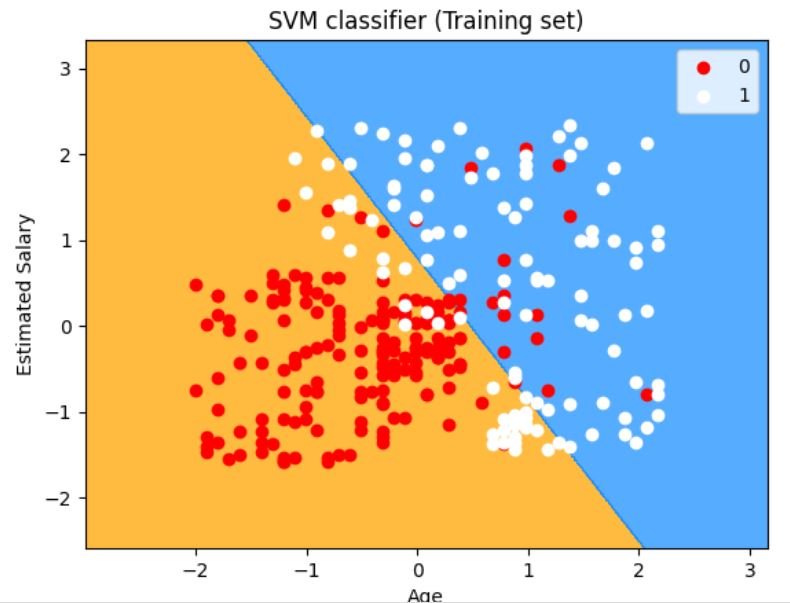



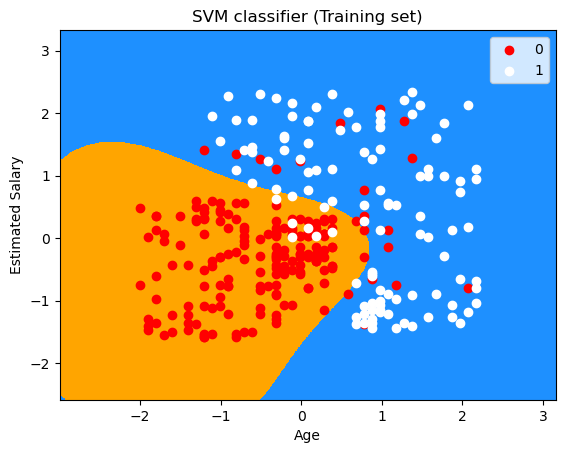

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

# 1. 撒格子點
x1, x2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
    np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
)

# 2. 每個格子點都讓模型預測
grid = np.c_[x1.ravel(), x2.ravel()]
Z = classifier.predict(grid).reshape(x1.shape)

# 3. 依照預測結果塗背景顏色
plt.contourf(x1, x2, Z, cmap=ListedColormap(['orange', 'dodgerblue']))

# 4. 畫真實的人
plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], c='red', label='0')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], c='white', label='1')

plt.title('SVM classifier (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


#**Regression(50%)**

Complete the following steps to generate data, train a Support Vector Regression (SVR) model, and visualize the results.



#1.Data Generation and Processing(10%)

Use make_regression generate a dataset with 1000 data points and three features, set the noise parameter to noise=5.0 to simulate real-world data variability and random_state=100 to ensure reproducibility of the results.



In [6]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=1000, n_features=3, noise=5.0, random_state=100)
print(X.shape, y.shape)

(1000, 3) (1000,)


#2.Standardize Data(5%)

Use StandardScaler to standardize the features, standardizing them to have a mean of 0 and a standard deviation of 1.

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)

#3.Train SVM model(5%)

Train a Support Vector Regression (SVR) model to predict the target variable.

In [8]:
from sklearn.svm import SVR

reg = SVR(kernel='linear')
reg.fit(X, y)

SVR(kernel='linear')

#4.Model Analysis and Output(30%)



*   Print Number of Support Vectors: Use reg.support_vectors_ to show the number of support vectors used by the model.
*   Print Prediction Samples: Select any 5 data points from the dataset and use reg.predict() to print the predicted values and compare them with the actual target values.
*   Print Mean Squared Error (MSE).



In [9]:
from sklearn.metrics import mean_squared_error

# (1) 支持向量的數量
print("Number of support vectors:", len(reg.support_vectors_))

# (2) 挑 5 筆資料，比較預測值和真實值
y_pred_5 = reg.predict(X[:5])
print("Predicted:", y_pred_5)
print("Actual:   ", y[:5])

# (3) MSE
y_pred = reg.predict(X)
print("MSE:", mean_squared_error(y, y_pred))


Number of support vectors: 978
Predicted: [-92.25636673 -22.11089477 113.22618321  55.9518912  304.88161843]
Actual:    [-98.18504608 -14.44883011 111.66127387  59.31207156 308.91463184]
MSE: 27.381975589953814
